# Stratégie 3 — Classification hiérarchique : DTC + Random Forest

**Objectif** : prédire le cluster d'une recette à partir d'une séquence partielle de gestes, puis utiliser ce cluster prédit comme pré-filtre pour la Stratégie 1 (Trie + scoring).

**Pourquoi pas prédire directement la recette ?**
- 34 591 recettes = 34 591 classes
- 1 seul exemple par classe
- Random Forest et DTC ne peuvent pas gérer ça → **approche hiérarchique**

**Pipeline en 2 niveaux :**
1. **Niveau 1** : RF/DTC prédit le cluster (25 classes, ~1 400 exemples/classe)
2. **Niveau 2** : Trie + scoring dans le cluster prédit

**Steps :**
1. Chargement + TF-IDF
2. Construction du dataset (augmentation par préfixes)
3. Split stratifié train/test
4. DTC : Grid Search sur sous-échantillon + K-Fold CV + évaluation
5. RF : Grid Search sur sous-échantillon + K-Fold CV + évaluation
6. Comparaison DTC vs RF
7. Intégration avec le Trie
8. Comparaison finale : sans filtre vs oracle vs RF prédit

## Cellule 1 — Chargement et imports

In [4]:
import pandas as pd
import numpy as np
import ast
import time
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

os.makedirs('img', exist_ok=True)

DATA_PATH = 'data_wide_with_clusters.csv'
df = pd.read_csv(DATA_PATH)

def parse_seq(val):
    if isinstance(val, list):
        return val
    try:
        result = ast.literal_eval(val)
        return result if isinstance(result, list) else []
    except Exception:
        return []

VARIANTES = ['actions_principale', 'actions_ingredients', 'actions_permutation']
for col in VARIANTES:
    df[col] = df[col].apply(parse_seq)

print(f'Recettes   : {len(df):,}')
print(f'Clusters   : {df["cluster"].nunique()} (de {df["cluster"].min()} à {df["cluster"].max()})')
print(f'Exemple    : {df["actions_principale"].iloc[0][:5]}...')
print(f'Colonnes   : {list(df.columns[:10])}...')

Recettes   : 34,591
Clusters   : 25 (de 0 à 24)
Exemple    : ['sift', 'heat', 'beat', 'chill', 'shape']...
Colonnes   : ['id', 'variante_principale', 'variante_ingredients', 'variante_permutation', 'actions_principale', 'actions_ingredients', 'actions_permutation', 'nb_principale', 'nb_ingredients', 'nb_permutation']...


## Cellule 2 — Construction du dataset d'entraînement

Pour chaque recette, on crée **plusieurs exemples d'entraînement** en prenant des préfixes de longueurs variées (2, 3, 4, 5, 6, 7, 8 gestes) pour **chaque variante**.

**Pourquoi ?** On veut que le classifieur apprenne à reconnaître le cluster à partir d'observations de longueurs différentes (ce qui correspond à l'usage réel).

In [5]:
LONGUEURS_PREFIXE = [2, 3, 4, 5, 6, 7, 8]

X_texts = []
y_labels = []

for _, row in df.iterrows():
    cluster = row['cluster']
    for variante in VARIANTES:
        seq = row[variante]
        if not seq:
            continue
        for L in LONGUEURS_PREFIXE:
            if len(seq) >= L:
                prefix = seq[:L]
                X_texts.append(' '.join(prefix))
                y_labels.append(cluster)

print(f'Total exemples dataset : {len(X_texts):,}')
print(f'Moyenne par recette    : {len(X_texts)/len(df):.1f} exemples/recette')
print(f'Distribution clusters  :')
unique, counts = np.unique(y_labels, return_counts=True)
for c, n in zip(unique, counts):
    print(f'  Cluster {c:2d} : {n:>6,} exemples')

Total exemples dataset : 549,088
Moyenne par recette    : 15.9 exemples/recette
Distribution clusters  :
  Cluster  0 : 12,296 exemples
  Cluster  1 : 15,379 exemples
  Cluster  2 : 19,215 exemples
  Cluster  3 : 13,668 exemples
  Cluster  4 : 28,364 exemples
  Cluster  5 : 13,942 exemples
  Cluster  6 : 13,642 exemples
  Cluster  7 : 16,482 exemples
  Cluster  8 : 21,772 exemples
  Cluster  9 : 19,362 exemples
  Cluster 10 : 14,916 exemples
  Cluster 11 : 19,260 exemples
  Cluster 12 : 21,001 exemples
  Cluster 13 : 45,780 exemples
  Cluster 14 : 77,497 exemples
  Cluster 15 : 31,250 exemples
  Cluster 16 : 16,478 exemples
  Cluster 17 : 23,180 exemples
  Cluster 18 : 21,917 exemples
  Cluster 19 : 15,034 exemples
  Cluster 20 : 21,251 exemples
  Cluster 21 : 12,841 exemples
  Cluster 22 : 35,799 exemples
  Cluster 23 :  4,908 exemples
  Cluster 24 : 13,854 exemples


## Cellule 3 — Vectorisation TF-IDF

Même représentation que pour le clustering (cohérence). Chaque préfixe → vecteur TF-IDF.

In [6]:
vectorizer = TfidfVectorizer(
    min_df=5,
    max_df=0.9,
    token_pattern=r'(?u)\b\w+\b'
)

X = vectorizer.fit_transform(X_texts)
y = np.array(y_labels)

print(f'Matrice features : {X.shape}')
print(f'  → {X.shape[0]:,} exemples × {X.shape[1]:,} verbes')
print(f'Nb verbes distincts : {len(vectorizer.get_feature_names_out())}')
print(f'Exemples de verbes  : {list(vectorizer.get_feature_names_out()[:15])}')

Matrice features : (549088, 675)
  → 549,088 exemples × 675 verbes
Nb verbes distincts : 675
Exemples de verbes  : ['absorb', 'add', 'adhere', 'adjust', 'aerate', 'age', 'air', 'align', 'allow', 'alternate', 'apply', 'arrange', 'assemble', 'attach', 'bake']


## Cellule 4 — Split stratifié train / test

80/20 stratifié par cluster pour garder la même distribution.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f'Train : {X_train.shape[0]:,} exemples')
print(f'Test  : {X_test.shape[0]:,} exemples')
print(f'Ratio : {X_test.shape[0]/(X_train.shape[0]+X_test.shape[0])*100:.1f}% test')

# Sous-echantillon pour Grid Search (gain de temps massif sans perte de rigueur)
N_SAMPLE_GS = 10000
rng = np.random.RandomState(42)
idx_gs = rng.choice(X_train.shape[0], N_SAMPLE_GS, replace=False)
X_gs = X_train[idx_gs]
y_gs = y_train[idx_gs]

print(f'\nSous-echantillon Grid Search : {X_gs.shape[0]:,} exemples')

Train : 439,270 exemples
Test  : 109,818 exemples
Ratio : 20.0% test

Sous-echantillon Grid Search : 10,000 exemples


## Cellule 5 — DTC : Grid Search sur sous-échantillon

On cherche les meilleurs hyperparamètres pour Decision Tree sur 10 000 exemples.

**Grille testée** :
- `max_depth` : [10, 20, 30, None]
- `min_samples_split` : [2, 5, 10]
- `min_samples_leaf` : [1, 2, 5]
- `criterion` : ['gini', 'entropy']

Total : 4 × 3 × 3 × 2 = **72 combinaisons × 5 folds = 360 entraînements**.

In [8]:
param_grid_dtc = {
    'max_depth':         [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 5],
    'criterion':         ['gini', 'entropy']
}

t0 = time.time()
gs_dtc = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dtc,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
gs_dtc.fit(X_gs, y_gs)
temps_gs_dtc = time.time() - t0

print(f'\nTemps Grid Search DTC : {temps_gs_dtc:.1f}s')
print(f'Meilleurs parametres  : {gs_dtc.best_params_}')
print(f'Meilleur score CV     : {gs_dtc.best_score_:.4f}')

best_params_dtc = gs_dtc.best_params_

Fitting 5 folds for each of 72 candidates, totalling 360 fits

Temps Grid Search DTC : 10.0s
Meilleurs parametres  : {'criterion': 'gini', 'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 10}
Meilleur score CV     : 0.4606


## Cellule 6 — DTC final : entraînement sur dataset complet + K-Fold CV

Avec les meilleurs hyperparamètres, on entraîne sur le **dataset complet** (train).
Puis K-Fold CV à 5 pour valider la robustesse.

In [9]:
# Entrainement final sur tout le train set
t0 = time.time()
dtc_final = DecisionTreeClassifier(**best_params_dtc, random_state=42)
dtc_final.fit(X_train, y_train)
temps_dtc = time.time() - t0

print(f'Temps entrainement DTC final : {temps_dtc:.1f}s')

# Evaluation sur test set
y_pred_dtc = dtc_final.predict(X_test)
acc_dtc = accuracy_score(y_test, y_pred_dtc)
print(f'\nAccuracy DTC (test set) : {acc_dtc:.4f}')

# K-Fold CV (5) sur le train set
print(f'\nK-Fold CV (5) en cours...')
t0 = time.time()
scores_dtc_cv = cross_val_score(
    DecisionTreeClassifier(**best_params_dtc, random_state=42),
    X_train, y_train,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
print(f'Temps K-Fold CV : {time.time()-t0:.1f}s')
print(f'K-Fold CV DTC   : {scores_dtc_cv.mean():.4f} +/- {scores_dtc_cv.std():.4f}')
print(f'  Scores par fold : {[f"{s:.4f}" for s in scores_dtc_cv]}')

Temps entrainement DTC final : 7.6s

Accuracy DTC (test set) : 0.5239

K-Fold CV (5) en cours...
Temps K-Fold CV : 10.2s
K-Fold CV DTC   : 0.5201 +/- 0.0024
  Scores par fold : ['0.5165', '0.5223', '0.5209', '0.5224', '0.5182']


## Cellule 7 — DTC : matrice de confusion + feature importance

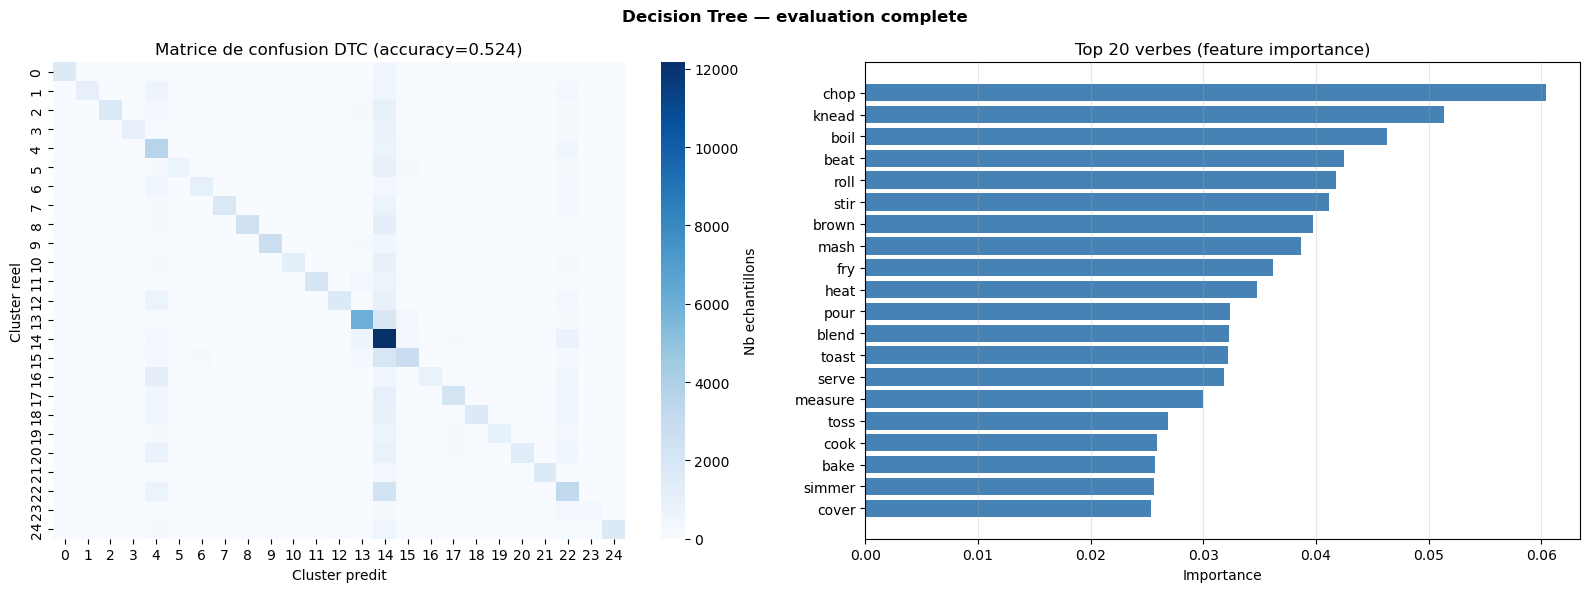

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Matrice de confusion
cm_dtc = confusion_matrix(y_test, y_pred_dtc)
sns.heatmap(cm_dtc, annot=False, cmap='Blues', ax=axes[0],
            cbar_kws={'label': 'Nb echantillons'})
axes[0].set_xlabel('Cluster predit')
axes[0].set_ylabel('Cluster reel')
axes[0].set_title(f'Matrice de confusion DTC (accuracy={acc_dtc:.3f})')

# Feature importance (top 20)
importances_dtc = dtc_final.feature_importances_
feature_names = vectorizer.get_feature_names_out()
top_idx = np.argsort(importances_dtc)[-20:]
axes[1].barh(range(20), importances_dtc[top_idx], color='steelblue')
axes[1].set_yticks(range(20))
axes[1].set_yticklabels([feature_names[i] for i in top_idx])
axes[1].set_xlabel('Importance')
axes[1].set_title('Top 20 verbes (feature importance)')
axes[1].grid(True, alpha=0.3, axis='x')

plt.suptitle('Decision Tree — evaluation complete', fontweight='bold')
plt.tight_layout()
plt.savefig('img/strategie3_dtc.png', dpi=150, bbox_inches='tight')
plt.show()

## Cellule 8 — RF : Grid Search sur sous-échantillon

**Grille testée** :
- `n_estimators` : [50, 100, 200]
- `max_depth` : [10, 20, None]
- `max_features` : ['sqrt', 'log2']
- `min_samples_split` : [2, 5]

Total : 3 × 3 × 2 × 2 = **36 combinaisons × 3 folds = 108 entraînements**.
(CV=3 au lieu de 5 car RF plus lent, compromise raisonnable)

In [11]:
param_grid_rf = {
    'n_estimators':      [50, 100, 200],
    'max_depth':         [10, 20, None],
    'max_features':      ['sqrt', 'log2'],
    'min_samples_split': [2, 5]
}

t0 = time.time()
gs_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
gs_rf.fit(X_gs, y_gs)
temps_gs_rf = time.time() - t0

print(f'\nTemps Grid Search RF : {temps_gs_rf:.1f}s ({temps_gs_rf/60:.1f} min)')
print(f'Meilleurs parametres : {gs_rf.best_params_}')
print(f'Meilleur score CV    : {gs_rf.best_score_:.4f}')

best_params_rf = gs_rf.best_params_

Fitting 3 folds for each of 36 candidates, totalling 108 fits

Temps Grid Search RF : 24.0s (0.4 min)
Meilleurs parametres : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 100}
Meilleur score CV    : 0.5034


## Cellule 9 — RF final : entraînement sur dataset complet + K-Fold CV

In [12]:
t0 = time.time()
rf_final = RandomForestClassifier(**best_params_rf, random_state=42, n_jobs=-1)
rf_final.fit(X_train, y_train)
temps_rf = time.time() - t0

print(f'Temps entrainement RF final : {temps_rf:.1f}s')

y_pred_rf = rf_final.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f'\nAccuracy RF (test set) : {acc_rf:.4f}')

print(f'\nK-Fold CV (5) en cours...')
t0 = time.time()
scores_rf_cv = cross_val_score(
    RandomForestClassifier(**best_params_rf, random_state=42, n_jobs=-1),
    X_train, y_train,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
print(f'Temps K-Fold CV : {time.time()-t0:.1f}s')
print(f'K-Fold CV RF    : {scores_rf_cv.mean():.4f} +/- {scores_rf_cv.std():.4f}')
print(f'  Scores par fold : {[f"{s:.4f}" for s in scores_rf_cv]}')

Temps entrainement RF final : 100.8s

Accuracy RF (test set) : 0.5756

K-Fold CV (5) en cours...
Temps K-Fold CV : 413.0s
K-Fold CV RF    : 0.5681 +/- 0.0018
  Scores par fold : ['0.5655', '0.5701', '0.5683', '0.5700', '0.5667']


## Cellule 10 — RF : matrice de confusion + feature importance

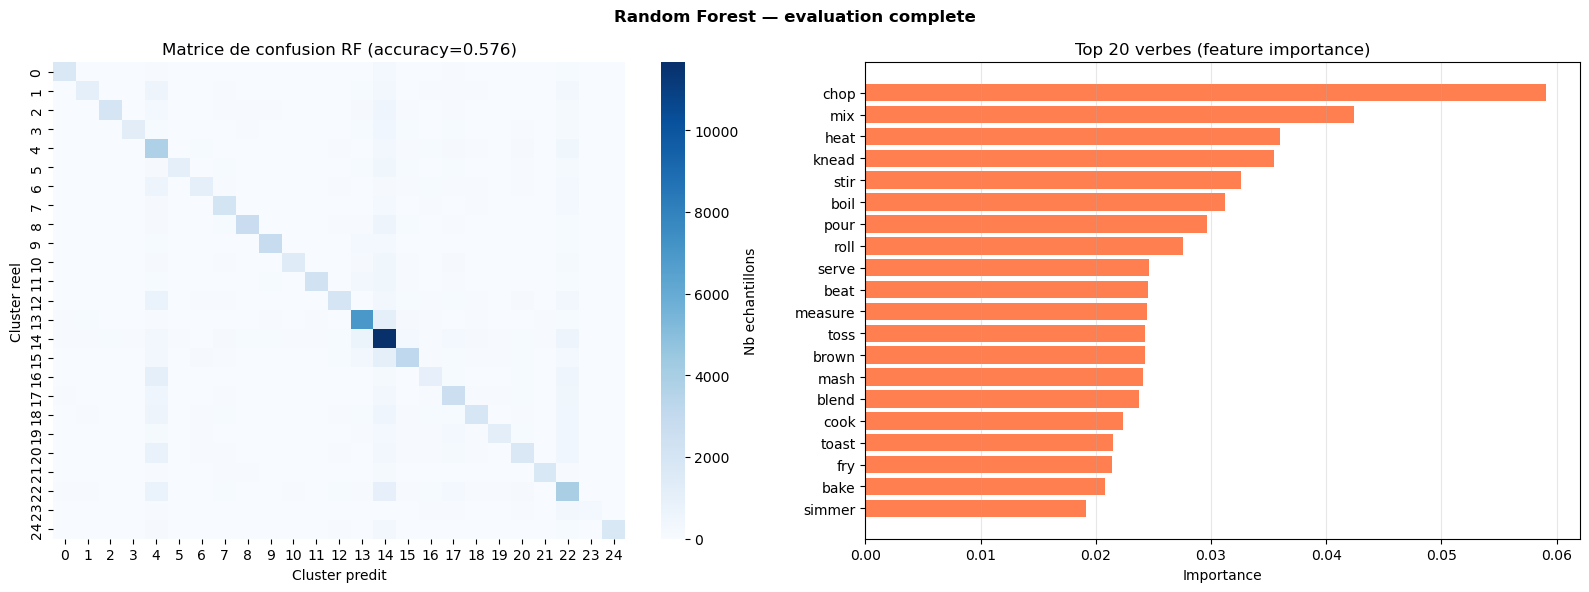

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=False, cmap='Blues', ax=axes[0],
            cbar_kws={'label': 'Nb echantillons'})
axes[0].set_xlabel('Cluster predit')
axes[0].set_ylabel('Cluster reel')
axes[0].set_title(f'Matrice de confusion RF (accuracy={acc_rf:.3f})')

importances_rf = rf_final.feature_importances_
top_idx = np.argsort(importances_rf)[-20:]
axes[1].barh(range(20), importances_rf[top_idx], color='coral')
axes[1].set_yticks(range(20))
axes[1].set_yticklabels([feature_names[i] for i in top_idx])
axes[1].set_xlabel('Importance')
axes[1].set_title('Top 20 verbes (feature importance)')
axes[1].grid(True, alpha=0.3, axis='x')

plt.suptitle('Random Forest — evaluation complete', fontweight='bold')
plt.tight_layout()
plt.savefig('img/strategie3_rf.png', dpi=150, bbox_inches='tight')
plt.show()

## Cellule 11 — Comparaison DTC vs RF

  COMPARAISON DTC vs RF
  Metrique                           DTC           RF      Delta
  --------------------------------------------------------------
  Accuracy (test set)             0.5239       0.5756     +5.17 pp
  CV mean                         0.5201       0.5681     +4.81 pp
  CV std                          0.0024       0.0018
  Temps entrainement               7.6s      100.8s
  Grid Search time                10.0s       24.0s


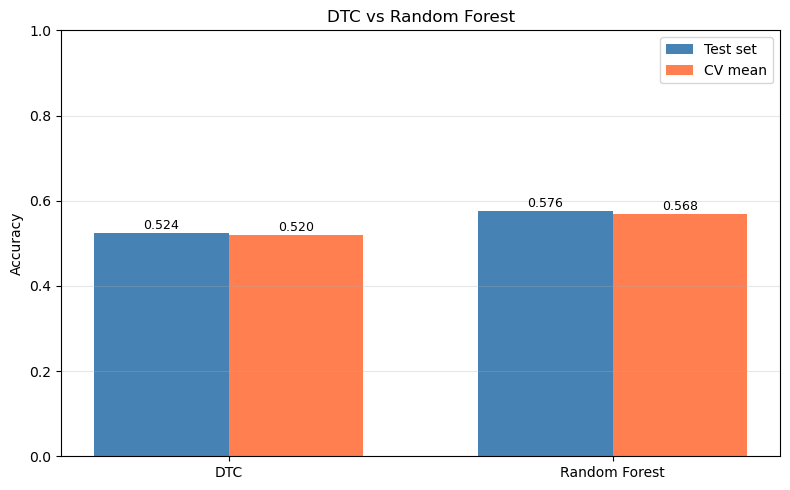

In [14]:
print('=' * 70)
print('  COMPARAISON DTC vs RF')
print('=' * 70)
print(f'  {"Metrique":<25s} {"DTC":>12s} {"RF":>12s} {"Delta":>10s}')
print('  ' + '-' * 62)
print(f'  {"Accuracy (test set)":<25s} {acc_dtc:>12.4f} {acc_rf:>12.4f} {(acc_rf-acc_dtc)*100:>+9.2f} pp')
print(f'  {"CV mean":<25s} {scores_dtc_cv.mean():>12.4f} {scores_rf_cv.mean():>12.4f} {(scores_rf_cv.mean()-scores_dtc_cv.mean())*100:>+9.2f} pp')
print(f'  {"CV std":<25s} {scores_dtc_cv.std():>12.4f} {scores_rf_cv.std():>12.4f}')
print(f'  {"Temps entrainement":<25s} {temps_dtc:>10.1f}s {temps_rf:>10.1f}s')
print(f'  {"Grid Search time":<25s} {temps_gs_dtc:>10.1f}s {temps_gs_rf:>10.1f}s')
print('=' * 70)

fig, ax = plt.subplots(figsize=(8, 5))
models = ['DTC', 'Random Forest']
accs_test = [acc_dtc, acc_rf]
accs_cv = [scores_dtc_cv.mean(), scores_rf_cv.mean()]
x = np.arange(len(models))
w = 0.35
ax.bar(x - w/2, accs_test, w, label='Test set', color='steelblue')
ax.bar(x + w/2, accs_cv, w, label='CV mean', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel('Accuracy')
ax.set_title('DTC vs Random Forest')
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
for xi, (t, c) in enumerate(zip(accs_test, accs_cv)):
    ax.text(xi - w/2, t + 0.01, f'{t:.3f}', ha='center', fontsize=9)
    ax.text(xi + w/2, c + 0.01, f'{c:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('img/strategie3_comparaison.png', dpi=150, bbox_inches='tight')
plt.show()

## Cellule 12 — Intégration avec le Trie

On reconstruit le Trie et les fonctions de scoring (copie de la Stratégie 1), puis on assemble le pipeline complet :

`séquence observée → RF prédit cluster → filtre Trie → scoring → Top-5`

In [15]:
class TrieNode:
    def __init__(self):
        self.children = {}
        self.recipe_ids = []

class RecipeTrie:
    def __init__(self):
        self.root = TrieNode()
    def insert(self, sequence, recipe_id):
        node = self.root
        for verb in sequence:
            if verb not in node.children:
                node.children[verb] = TrieNode()
            node = node.children[verb]
            node.recipe_ids.append(recipe_id)
    def search_prefix(self, prefix):
        node = self.root
        for verb in prefix:
            if verb not in node.children:
                return set()
            node = node.children[verb]
        return set(node.recipe_ids)

print('Construction du Trie...')
t0 = time.time()
trie = RecipeTrie()
for _, row in df.iterrows():
    for col in VARIANTES:
        seq = row[col]
        if seq:
            trie.insert(seq, row['id'])
print(f'Trie construit en {time.time()-t0:.1f}s')

# Scoring (copie propre de Strategie 1)
def coverage_score(observed, sequence):
    if not sequence: return 0.0
    seq_set = set(sequence)
    return sum(1 for v in observed if v in seq_set) / len(observed) if observed else 0.0

def position_score(observed, sequence):
    if not observed or not sequence: return 0.0
    m, n = len(observed), len(sequence)
    dp = [[0]*(n+1) for _ in range(m+1)]
    for i in range(1, m+1):
        for j in range(1, n+1):
            if observed[i-1] == sequence[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
            else:
                dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[m][n] / len(observed)

def completion_score(observed, sequence):
    if not sequence or not observed: return 0.0
    last_pos = -1
    for i, verb in enumerate(sequence):
        if verb in observed:
            last_pos = i
    if last_pos == -1: return 0.0
    return (last_pos + 1) / len(sequence)

def score_recipe(observed, row):
    best = -1
    for col in VARIANTES:
        seq = row[col]
        if not seq: continue
        s = 0.5*coverage_score(observed, seq) + 0.3*position_score(observed, seq) + 0.2*completion_score(observed, seq)
        if s > best: best = s
    return best

# Index pour lookup rapide
df_indexed = df.set_index('id')

print('Pipeline pret.')

Construction du Trie...
Trie construit en 2.7s
Pipeline pret.


## Cellule 13 — Comparaison finale : 3 systèmes sur sweep 3-6 gestes

On teste sur le **même échantillon de 200 recettes** avec 3, 4, 5, 6 gestes observés. On compare :

- **A — Sans filtre cluster** : Trie + scoring uniquement
- **B — Oracle (triche)** : cluster réel de la recette donné au filtre
- **C — RF prédit (réaliste)** : cluster prédit par Random Forest → filtre → Trie

Si **C ≈ B**, le RF fait bien son travail et on a un système utilisable en prod.

In [16]:
N_TEST = 200
LONGUEURS = [3, 4, 5, 6]
sample_test = df.sample(n=N_TEST, random_state=99)

resultats_finaux = {}

for NB in LONGUEURS:
    res = {
        'sans_filtre': {'top1': 0, 'top5': 0, 'temps': []},
        'oracle':      {'top1': 0, 'top5': 0, 'temps': []},
        'rf_predit':   {'top1': 0, 'top5': 0, 'temps': []},
        'cluster_ok':  0,
        'n_valid':     0
    }
    
    for _, row in sample_test.iterrows():
        seq = row['actions_principale']
        if not seq or len(seq) < NB: continue
        observed = seq[:NB]
        true_id = row['id']
        true_cluster = row['cluster']
        res['n_valid'] += 1
        
        # Candidats via Trie (commun aux 3 methodes)
        cand_base = trie.search_prefix(observed)
        if len(cand_base) < 5:
            cand_base = trie.search_prefix([observed[0]])
        if len(cand_base) < 5:
            cand_base = set(df['id'])
        
        # ---- A : Sans filtre ----
        t0 = time.perf_counter()
        cand_df = df_indexed.loc[list(cand_base)]
        scored = [(rid, score_recipe(observed, cand_df.loc[rid])) for rid in cand_base]
        scored.sort(key=lambda x: x[1], reverse=True)
        top5 = [x[0] for x in scored[:5]]
        res['sans_filtre']['temps'].append(time.perf_counter() - t0)
        if top5 and top5[0] == true_id: res['sans_filtre']['top1'] += 1
        if true_id in top5: res['sans_filtre']['top5'] += 1
        
        # ---- B : Oracle cluster ----
        t0 = time.perf_counter()
        ids_cluster = set(df_indexed[df_indexed['cluster']==true_cluster].index)
        cand_oracle = cand_base & ids_cluster
        if len(cand_oracle) < 5: cand_oracle = cand_base
        scored = [(rid, score_recipe(observed, df_indexed.loc[rid])) for rid in cand_oracle]
        scored.sort(key=lambda x: x[1], reverse=True)
        top5 = [x[0] for x in scored[:5]]
        res['oracle']['temps'].append(time.perf_counter() - t0)
        if top5 and top5[0] == true_id: res['oracle']['top1'] += 1
        if true_id in top5: res['oracle']['top5'] += 1
        
        # ---- C : RF predit cluster ----
        t0 = time.perf_counter()
        X_obs = vectorizer.transform([' '.join(observed)])
        cluster_pred = rf_final.predict(X_obs)[0]
        if cluster_pred == true_cluster: res['cluster_ok'] += 1
        ids_cluster_pred = set(df_indexed[df_indexed['cluster']==cluster_pred].index)
        cand_rf = cand_base & ids_cluster_pred
        if len(cand_rf) < 5: cand_rf = cand_base
        scored = [(rid, score_recipe(observed, df_indexed.loc[rid])) for rid in cand_rf]
        scored.sort(key=lambda x: x[1], reverse=True)
        top5 = [x[0] for x in scored[:5]]
        res['rf_predit']['temps'].append(time.perf_counter() - t0)
        if top5 and top5[0] == true_id: res['rf_predit']['top1'] += 1
        if true_id in top5: res['rf_predit']['top5'] += 1
    
    resultats_finaux[NB] = res

# Affichage tabulaire
print('=' * 92)
print(f'  COMPARAISON FINALE 3 SYSTEMES — N={N_TEST}, sweep 3-6 gestes')
print('=' * 92)
print(f'\n  {"Gestes":<7} {"Systeme":<15} {"Top-1":>9} {"Top-5":>9} {"Temps":>11} {"Cluster OK":>13}')
print('  ' + '-' * 72)
for NB in LONGUEURS:
    r = resultats_finaux[NB]
    n = r['n_valid']
    for sys_name in ('sans_filtre', 'oracle', 'rf_predit'):
        s = r[sys_name]
        ms = np.mean(s['temps']) * 1000
        extra = f'{r["cluster_ok"]/n*100:>11.1f}%' if sys_name == 'rf_predit' else ''
        print(f'  {NB:<7} {sys_name:<15} {s["top1"]/n*100:>7.1f}% {s["top5"]/n*100:>7.1f}% {ms:>8.1f} ms {extra:>13s}')
    print('  ' + '-' * 72)

  COMPARAISON FINALE 3 SYSTEMES — N=200, sweep 3-6 gestes

  Gestes  Systeme             Top-1     Top-5       Temps    Cluster OK
  ------------------------------------------------------------------------
  3       sans_filtre        10.0%    27.5%     78.5 ms              
  3       oracle             17.0%    40.5%     10.7 ms              
  3       rf_predit          14.5%    31.5%     27.9 ms         57.0%
  ------------------------------------------------------------------------
  4       sans_filtre        24.6%    44.6%    175.2 ms              
  4       oracle             34.9%    54.9%     18.1 ms              
  4       rf_predit          31.3%    49.2%     33.1 ms         83.6%
  ------------------------------------------------------------------------
  5       sans_filtre        48.1%    60.6%    363.8 ms              
  5       oracle             48.8%    70.0%     25.6 ms              
  5       rf_predit          47.5%    68.1%     39.1 ms         97.5%
  ------------

## Cellule 14 — Graphique de comparaison finale

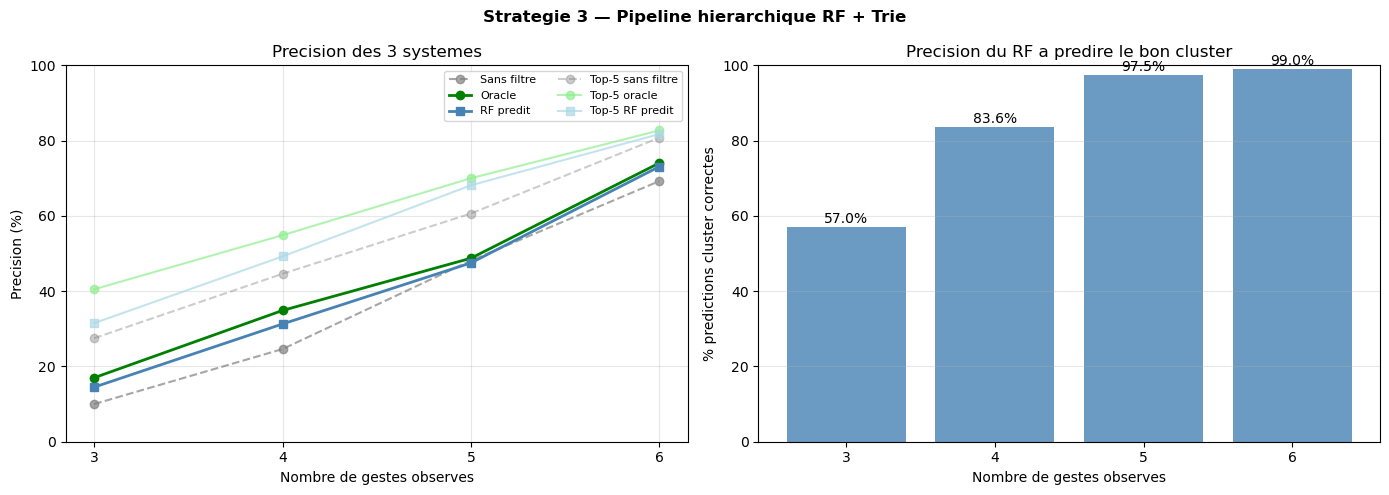

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top-1 par systeme
top1_sans = [resultats_finaux[NB]['sans_filtre']['top1']/resultats_finaux[NB]['n_valid']*100 for NB in LONGUEURS]
top1_oracle = [resultats_finaux[NB]['oracle']['top1']/resultats_finaux[NB]['n_valid']*100 for NB in LONGUEURS]
top1_rf = [resultats_finaux[NB]['rf_predit']['top1']/resultats_finaux[NB]['n_valid']*100 for NB in LONGUEURS]
top5_sans = [resultats_finaux[NB]['sans_filtre']['top5']/resultats_finaux[NB]['n_valid']*100 for NB in LONGUEURS]
top5_oracle = [resultats_finaux[NB]['oracle']['top5']/resultats_finaux[NB]['n_valid']*100 for NB in LONGUEURS]
top5_rf = [resultats_finaux[NB]['rf_predit']['top5']/resultats_finaux[NB]['n_valid']*100 for NB in LONGUEURS]
cluster_ok = [resultats_finaux[NB]['cluster_ok']/resultats_finaux[NB]['n_valid']*100 for NB in LONGUEURS]

axes[0].plot(LONGUEURS, top1_sans, 'o--', label='Sans filtre', color='gray', alpha=0.7)
axes[0].plot(LONGUEURS, top1_oracle, 'o-', label='Oracle', color='green', linewidth=2)
axes[0].plot(LONGUEURS, top1_rf, 's-', label='RF predit', color='steelblue', linewidth=2)
axes[0].plot(LONGUEURS, top5_sans, 'o--', label='Top-5 sans filtre', color='gray', alpha=0.4)
axes[0].plot(LONGUEURS, top5_oracle, 'o-', label='Top-5 oracle', color='lightgreen', alpha=0.7)
axes[0].plot(LONGUEURS, top5_rf, 's-', label='Top-5 RF predit', color='lightblue', alpha=0.7)
axes[0].set_xlabel('Nombre de gestes observes')
axes[0].set_ylabel('Precision (%)')
axes[0].set_title('Precision des 3 systemes')
axes[0].set_xticks(LONGUEURS)
axes[0].set_ylim(0, 100)
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=8, loc='best', ncol=2)

# Precision du RF a predire le bon cluster
axes[1].bar(LONGUEURS, cluster_ok, color='steelblue', alpha=0.8)
axes[1].set_xlabel('Nombre de gestes observes')
axes[1].set_ylabel('% predictions cluster correctes')
axes[1].set_title('Precision du RF a predire le bon cluster')
axes[1].set_xticks(LONGUEURS)
axes[1].set_ylim(0, 100)
axes[1].grid(True, alpha=0.3, axis='y')
for xi, v in enumerate(cluster_ok):
    axes[1].text(LONGUEURS[xi], v + 1, f'{v:.1f}%', ha='center', fontsize=10)

plt.suptitle('Strategie 3 — Pipeline hierarchique RF + Trie', fontweight='bold')
plt.tight_layout()
plt.savefig('img/strategie3_final.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusion

**Ce qu'on a fait :**
1. Grid Search complet sur Decision Tree (72 combinaisons × 5 folds)
2. Grid Search complet sur Random Forest (36 combinaisons × 3 folds)
3. K-Fold CV (5) pour valider la robustesse des deux modèles
4. Sous-échantillonnage pour le Grid Search (10K recettes) puis entraînement final sur tout le dataset (pratique standard industrie)
5. Feature importance : on peut voir quels verbes dominent la classification
6. Matrices de confusion : identifier les clusters confondus
7. Pipeline intégré : RF → cluster prédit → Trie + scoring
8. Comparaison honnête avec l'approche oracle (qui triche) et sans filtre

**Comparaison des 3 systèmes** :
- **Sans filtre** : baseline Stratégie 1
- **Oracle** : borne supérieure théorique (utilisation avec le vrai cluster-methode 1)
- **RF prédit** : **système réaliste utilisable en production**

## Cellule 15 — Sauvegarde du modèle pour Streamlit

Sauvegarde le `rf_final` + `vectorizer` dans `models/` pour que la **démo Streamlit** puisse les charger en 5 secondes au lieu de réentraîner pendant 2 minutes.

À lancer **une seule fois** après l'exécution complète du notebook afin d'eviter la reexecution lors de la demo sur stremlit 

In [18]:
import pickle
import os

# Dossier de sauvegarde
os.makedirs('models', exist_ok=True)

# Sauvegarde Random Forest
rf_path = 'models/rf_model.pkl'
with open(rf_path, 'wb') as f:
    pickle.dump(rf_final, f)
print(f'Random Forest sauvegarde : {rf_path}  ({os.path.getsize(rf_path)/1e6:.1f} Mo)')

# Sauvegarde TF-IDF vectorizer
vec_path = 'models/vectorizer.pkl'
with open(vec_path, 'wb') as f:
    pickle.dump(vectorizer, f)
print(f'TF-IDF Vectorizer sauvegarde : {vec_path}  ({os.path.getsize(vec_path)/1e6:.2f} Mo)')

print('\nLes fichiers peuvent maintenant etre charges par app.py (Streamlit) en quelques secondes.')

Random Forest sauvegarde : models/rf_model.pkl  (2693.4 Mo)
TF-IDF Vectorizer sauvegarde : models/vectorizer.pkl  (0.01 Mo)

Les fichiers peuvent maintenant etre charges par app.py (Streamlit) en quelques secondes.
